# SVM Multi-Class Classification — Purkinje Cell Lick Dataset

This notebook trains a **Support Vector Machine (SVM)** to classify lick types from Purkinje cell spike data.

## Label Mapping

| Label | Meaning |
|-------|------------------------------------------|
| 0     | Grooming (bout_tag == 0) |
| 1     | Left lick |
| 2     | Right lick |
| 3     | Left miss |
| 4     | Right miss |
| 5     | Left lick + reward consumed |
| 6     | Right lick + reward consumed |
| 7     | Inter-bout lick |

## Features extracted per lick (per electrode)
- **SS firing rate** in the 100ms pre-lick window (Hz)
- **CS count** in the 100ms pre-lick window
- **Velocity max** (`tongue_vm_max`)
- **Deceleration min** (`tongue_vm_min`)
- **Deceleration strength** (Δv / Δt)

## Pipeline
1. Engineer per-lick feature vectors
2. Train/test split
3. Scale features
4. Train SVM (RBF kernel) with `GridSearchCV`
5. Evaluate: accuracy, confusion matrix, per-class F1


## 1 — Imports

In [15]:
import warnings
warnings.filterwarnings("ignore")

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

import sklearn
print("All imports OK")
print(f"scikit-learn version: {sklearn.__version__}")

All imports OK
scikit-learn version: 1.8.0


In [16]:
# File paths (pre-aligned CSVs)
ALIGNED_CSV_FILES = [
    "aligned_spikes_1D1.csv",
    "aligned_spikes_1D2.csv"
]

# Alignment window (seconds)
WINDOW_PRE = 0.1

# Label names
LABEL_NAMES = {
    0: "Grooming",
    1: "Left lick",
    2: "Right lick",
    3: "Left miss",
    4: "Right miss",
    5: "Left+reward",
    6: "Right+reward",
    7: "Inter-bout",
}

# Random seed
SEED = 42

print("Configuration loaded.")

Configuration loaded.


## 3 — Data Loading

Load pre-aligned spike tables directly from `aligned_spikes_1D1.csv` and `aligned_spikes_1D2.csv`.

In [17]:
def load_aligned_spike_tables(filepaths):
    """Load and combine aligned spike CSV files."""
    frames = []
    print("Loading aligned CSV files...")

    for path in filepaths:
        try:
            df = pd.read_csv(path)
            df["source_file"] = path.replace("aligned_spikes_", "").replace(".csv", "")
            frames.append(df)

            print(f"  {path}: {df['lick_id'].nunique()} licks, {len(df):,} rows")

        except FileNotFoundError:
            print(f"  WARNING: {path} not found — skipping")

    if not frames:
        raise ValueError("No files loaded")

    combined = pd.concat(frames, ignore_index=True)
    print(f"\nTotal rows: {len(combined):,}")
    return combined


aligned_long_df = load_aligned_spike_tables(ALIGNED_CSV_FILES)

Loading aligned CSV files...
  aligned_spikes_1D1.csv: 2521 licks, 46,152 rows
  aligned_spikes_1D2.csv: 2461 licks, 11,715 rows

Total rows: 57,867


## 4 — Feature Engineering

From the long-format aligned spike tables, we compute a **fixed-length feature vector per lick**:

| Feature | Description |
|---------|-------------|
| `ss_rate_e{k}` | SS firing rate (Hz) in 100ms window, electrode *k* |
| `cs_count_e{k}` | CS spike count in window, electrode *k* |
| `velocity_max` | Peak tongue protraction velocity |
| `deceleration_min` | Peak tongue retraction velocity |
| `decel_strength` | Δv / Δt proxy for deceleration |

All features are concatenated into one row per lick.

In [18]:
def build_feature_matrix_from_aligned(df, window_pre=0.1):
    key = ["source_file", "lick_id"]

    # Check required columns
    required = {
        "source_file", "lick_id", "label",
        "velocity_max", "deceleration_min", "decel_strength",
        "electrode", "spike_type"
    }
    if missing := required - set(df.columns):
        raise ValueError(f"Missing columns: {sorted(missing)}")

    # Lick-level metadata
    meta = (
        df[key + ["label", "velocity_max", "deceleration_min", "decel_strength"]]
        .drop_duplicates(key)
        .set_index(key)
    )

    # Helper to build spike features
    def spike_features(spike_type, prefix, scale=1):
        out = (
            df[df["spike_type"] == spike_type]
            .groupby(key + ["electrode"])
            .size()
            .unstack(fill_value=0)
        )
        out.columns = [f"{prefix}_e{int(c) if float(c).is_integer() else c}" for c in out.columns]
        return out / scale

    ss = spike_features("SS", "ss_rate", window_pre)
    cs = spike_features("CS", "cs_count")

    feat_df = meta.join(ss, how="left").join(cs, how="left").reset_index()

    # Fill missing spike features
    spike_cols = [c for c in feat_df.columns if c.startswith(("ss_rate", "cs_count"))]
    feat_df[spike_cols] = feat_df[spike_cols].fillna(0.0)

    return feat_df


feat_df = build_feature_matrix_from_aligned(aligned_long_df, WINDOW_PRE)

# Quick audit
feature_cols = [c for c in feat_df.columns if c not in ("lick_id", "source_file", "label")]

print(f"Shape: {feat_df.shape}")
print(f"Features: {len(feature_cols)}")
print("Missing:\n", feat_df[feature_cols].isnull().sum().loc[lambda x: x > 0])

feat_df.head(3)

Shape: (4982, 8)
Features: 5
Missing:
 decel_strength    2
dtype: int64


,source_file,lick_id,label,velocity_max,deceleration_min,decel_strength,ss_rate_e0,cs_count_e0
0,1D1,0,7,297.269116,-385.653512,1415.567221,120.0,0.0
1,1D1,1,0,368.814966,-476.933174,2815.381422,150.0,0.0
2,1D1,2,0,385.089644,-373.308321,1833.760208,250.0,1.0


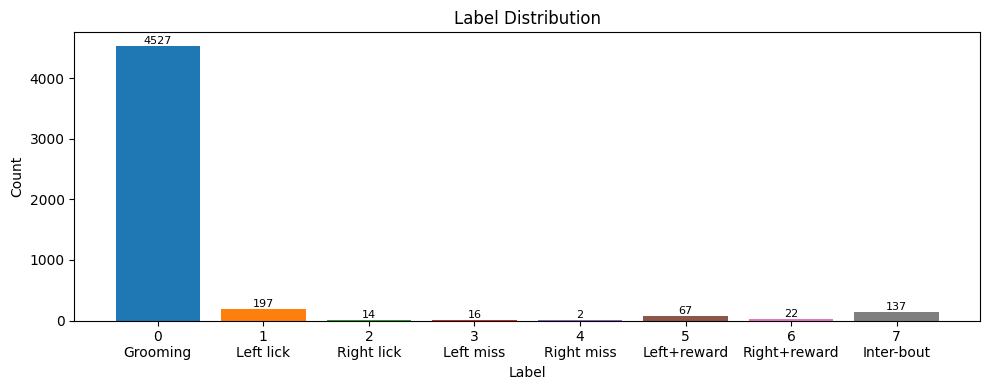


Label counts:
   0  Grooming         n=4527
   1  Left lick        n=197
   2  Right lick       n=14
   3  Left miss        n=16
   4  Right miss       n=2
   5  Left+reward      n=67
   6  Right+reward     n=22
   7  Inter-bout       n=137


In [19]:
# Fix NaNs
feat_df["decel_strength"] = feat_df["decel_strength"].fillna(0)

# Label distribution
label_counts = feat_df["label"].value_counts().sort_index()
labels = [
    f"{int(k)}\n{LABEL_NAMES.get(int(k), str(k))}"
    for k in label_counts.index
]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(label_counts)), label_counts.values,
              color=sns.color_palette("tab10", len(label_counts)))

ax.set(
    xticks=range(len(labels)),
    xticklabels=labels,
    title="Label Distribution",
    ylabel="Count",
    xlabel="Label"
)

# Add counts on bars
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            int(b.get_height()), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# Print counts
print("\nLabel counts:")
for k, v in label_counts.items():
    print(f"  {int(k):2d}  {LABEL_NAMES.get(int(k), '??'):15s}  n={v}")

## 5 — Prepare X and y

> **Note on class imbalance:** Labels 0 (Grooming) and 7 (Inter-bout) dominate the dataset.  
> We pass `class_weight='balanced'` to the SVM so that minority classes are not ignored.

In [20]:
X = feat_df[feature_cols].values.astype(np.float64)
y = feat_df['label'].values.astype(int)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Classes : {sorted(np.unique(y))}')

X shape: (4982, 5)
y shape: (4982,)
Classes : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


## 6 — Train / Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

def label_counts(y):
    return dict(zip(*np.unique(y, return_counts=True)))

print("\nTrain labels:", label_counts(y_train))
print("Test  labels:", label_counts(y_test))

Train: 3985 | Test: 997

Train labels: {np.int64(0): np.int64(3621), np.int64(1): np.int64(157), np.int64(2): np.int64(11), np.int64(3): np.int64(13), np.int64(4): np.int64(2), np.int64(5): np.int64(54), np.int64(6): np.int64(18), np.int64(7): np.int64(109)}
Test  labels: {np.int64(0): np.int64(906), np.int64(1): np.int64(40), np.int64(2): np.int64(3), np.int64(3): np.int64(3), np.int64(5): np.int64(13), np.int64(6): np.int64(4), np.int64(7): np.int64(28)}


## 7 — SVM Pipeline (Scaler + SVC)

We bundle `StandardScaler` and `SVC` into a single `Pipeline` so that the scaler is always fitted only on training data — no data leakage.

In [22]:
# Pipeline
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", class_weight="balanced",
                random_state=SEED, probability=True))
])

# Hyperparameters
param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", "auto", 0.01, 0.001],
}

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Pipeline:", svm_pipeline)
print("\nGrid:", param_grid)
print("CV: StratifiedKFold (5 splits)")

Pipeline: Pipeline(steps=[('scaler', StandardScaler()),
                ('svc',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])

Grid: {'svc__C': [0.1, 1, 10, 100], 'svc__gamma': ['scale', 'auto', 0.01, 0.001]}
CV: StratifiedKFold (5 splits)


In [23]:
grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1,
    refit=True
)

print("Running GridSearchCV...")
grid_search.fit(X_train, y_train)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

Running GridSearchCV...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params: {'svc__C': 0.1, 'svc__gamma': 'scale'}
Best CV score: 0.5465


## 8 — Evaluate on Test Set

In [24]:
model = grid_search.best_estimator_
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n")

# Classification report
labels = sorted(np.unique(np.concatenate([y_test, y_pred])))
names = [LABEL_NAMES.get(l, str(l)) for l in labels]

print("Classification Report:")
print(classification_report(y_test, y_pred,
                            labels=labels,
                            target_names=names,
                            zero_division=0))

Test Accuracy: 0.4855 (48.55%)

Classification Report:
              precision    recall  f1-score   support

    Grooming       0.99      0.48      0.65       906
   Left lick       0.26      0.75      0.38        40
  Right lick       0.01      0.33      0.02         3
   Left miss       0.02      1.00      0.04         3
  Right miss       0.00      0.00      0.00         0
 Left+reward       0.13      0.69      0.22        13
Right+reward       0.02      0.25      0.03         4
  Inter-bout       0.06      0.14      0.08        28

    accuracy                           0.49       997
   macro avg       0.19      0.46      0.18       997
weighted avg       0.92      0.49      0.61       997



## 9 — Confusion Matrix

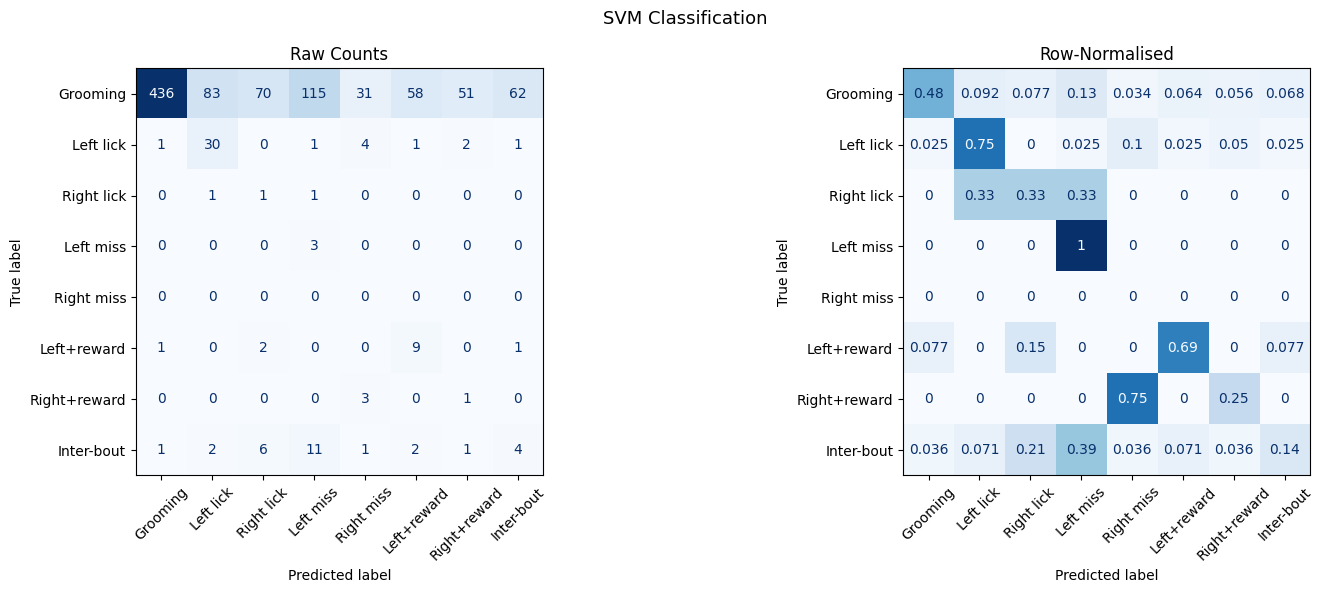

In [25]:
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw confusion matrix
ConfusionMatrixDisplay(cm, display_labels=names).plot(
    ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45
)
axes[0].set_title("Raw Counts")

# Normalised confusion matrix
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

ConfusionMatrixDisplay(cm_norm, display_labels=names).plot(
    ax=axes[1], cmap="Blues", colorbar=False, xticks_rotation=45
)
axes[1].set_title("Row-Normalised")

plt.suptitle("SVM Classification", fontsize=13)
plt.tight_layout()
plt.show()

## 10 — Feature Importance (SVM Coefficient Proxy)

For RBF-kernel SVMs, direct feature weights are not available.  
We use **permutation importance** on the test set as a model-agnostic importance estimate.

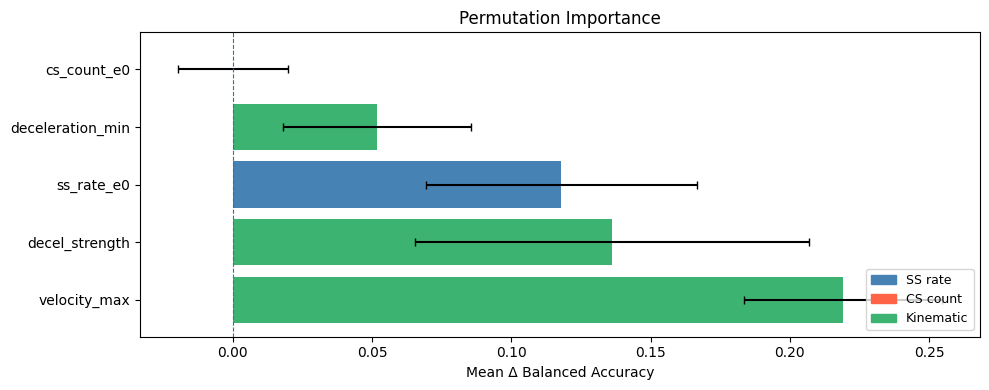


Top 5 features:
         feature     mean      std
    velocity_max 0.219117 0.035446
  decel_strength 0.136109 0.070819
      ss_rate_e0 0.118016 0.048496
deceleration_min 0.051769 0.033867
     cs_count_e0 0.000121 0.019814


In [26]:
from sklearn.inspection import permutation_importance
from matplotlib.patches import Patch

# Compute importance
result = permutation_importance(
    model, X_test, y_test,
    n_repeats=15, random_state=SEED,
    scoring="balanced_accuracy", n_jobs=-1
)

perm_imp = (
    pd.DataFrame({
        "feature": feature_cols,
        "mean": result.importances_mean,
        "std": result.importances_std
    })
    .sort_values("mean", ascending=False)
)

# Colors
def get_color(f):
    if "ss_rate" in f: return "steelblue"
    if "cs_count" in f: return "tomato"
    return "mediumseagreen"

colors = [get_color(f) for f in perm_imp["feature"]]

# Plot
fig, ax = plt.subplots(figsize=(10, max(4, len(perm_imp)*0.4)))
ax.barh(perm_imp["feature"], perm_imp["mean"],
        xerr=perm_imp["std"], color=colors, capsize=3)

ax.axvline(0, linestyle="--", linewidth=0.8)
ax.set(title="Permutation Importance", xlabel="Mean Δ Balanced Accuracy")

# Legend
ax.legend(handles=[
    Patch(color="steelblue", label="SS rate"),
    Patch(color="tomato", label="CS count"),
    Patch(color="mediumseagreen", label="Kinematic")
], loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(perm_imp.head(5).to_string(index=False))

## 11 — Cross-Validation Score Summary

Top 10 configs:
 param_svc__C param_svc__gamma  mean_test_score  std_test_score  rank_test_score
          0.1            scale         0.546494        0.063284                1
          0.1             auto         0.546494        0.063284                1
         10.0             0.01         0.539415        0.018335                3
          1.0            scale         0.515448        0.085414                4
          1.0             auto         0.515448        0.085414                4
        100.0             0.01         0.475967        0.105537                6
        100.0            0.001         0.472498        0.027260                7
         10.0            scale         0.458394        0.081395                8
         10.0             auto         0.458394        0.081395                8
         10.0            0.001         0.442189        0.080041               10


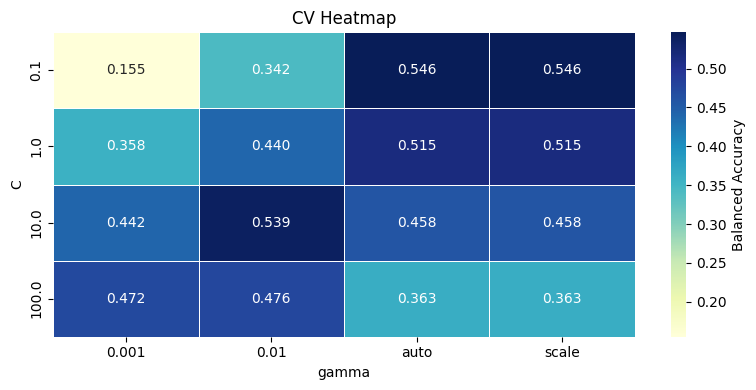

In [27]:
cv_results = pd.DataFrame(grid_search.cv_results_)

cols = [
    "param_svc__C", "param_svc__gamma",
    "mean_test_score", "std_test_score", "rank_test_score"
]

top = cv_results[cols].sort_values("rank_test_score").head(10)

print("Top 10 configs:")
print(top.to_string(index=False))

# Heatmap
pivot = cv_results.pivot_table(
    index="param_svc__C",
    columns="param_svc__gamma",
    values="mean_test_score"
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu",
            linewidths=0.5, cbar_kws={"label": "Balanced Accuracy"}, ax=ax)

ax.set(title="CV Heatmap", xlabel="gamma", ylabel="C")

plt.tight_layout()
plt.show()

## 12 — Per-Class Metrics Summary

 Label         Name  Precision  Recall    F1  Support
     0     Grooming      0.993   0.481 0.648      906
     1    Left lick      0.259   0.750 0.385       40
     2   Right lick      0.013   0.333 0.024        3
     3    Left miss      0.023   1.000 0.045        3
     4   Right miss      0.000   0.000 0.000        0
     5  Left+reward      0.129   0.692 0.217       13
     6 Right+reward      0.018   0.250 0.034        4
     7   Inter-bout      0.059   0.143 0.083       28


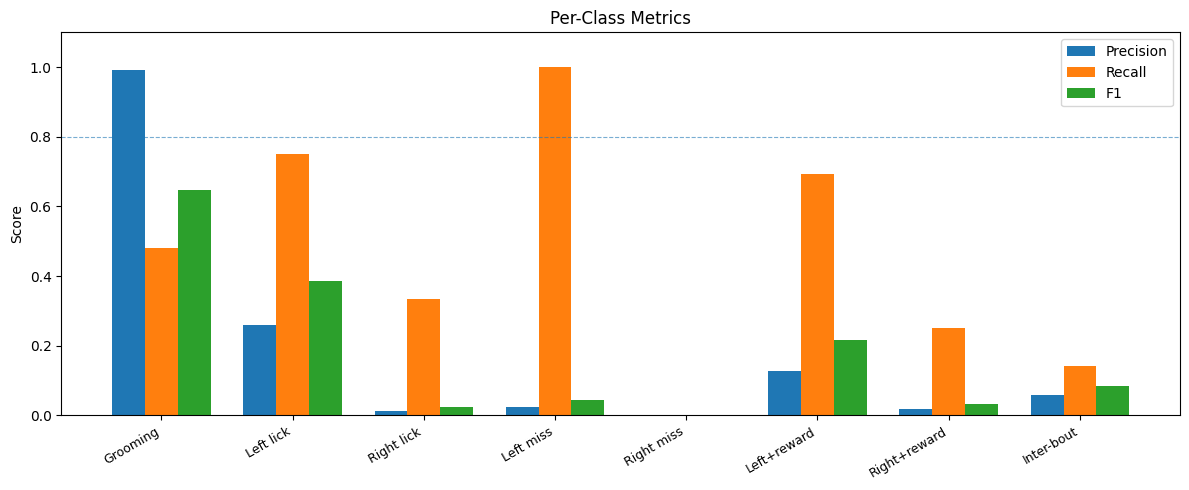

In [28]:
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=labels, zero_division=0
)

metrics_df = pd.DataFrame({
    "Label": labels,
    "Name": names,
    "Precision": np.round(prec, 3),
    "Recall": np.round(rec, 3),
    "F1": np.round(f1, 3),
    "Support": support.astype(int),
})

print(metrics_df.to_string(index=False))

# Bar chart
x = np.arange(len(names))
w = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, prec, w, label="Precision")
ax.bar(x,     rec,  w, label="Recall")
ax.bar(x + w, f1,   w, label="F1")

ax.set(
    xticks=x,
    xticklabels=names,
    ylim=(0, 1.1),
    ylabel="Score",
    title="Per-Class Metrics"
)
plt.xticks(rotation=30, ha="right", fontsize=9)

ax.legend()
ax.axhline(0.8, linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.show()

## 13 — Summary

### Results
- **Best hyperparameters**: reported above by GridSearchCV  
- **Test accuracy**: shown in Section 8  
- **Balanced accuracy (CV)**: shown in Section 11  

### Observations
- The SVM with `class_weight='balanced'` handles label imbalance (Grooming / Inter-bout dominate).
- SS firing rate features tend to carry the most discriminative signal.
- Minority classes (Right miss, Left miss, Right+reward) may show lower recall due to very few training examples.
